# 01. Modele nieparametryczne

            Notebook odtwarza część nieparametryczną prezentacji: opis danych, cenzurowanie, estymator Kaplana-Meiera, tablicę aktuarialną, estymator Nelsona-Aalena, wygładzony hazard oraz testy dla podgrup.


## Import bibliotek i przygotowanie danych


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

def find_act_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        candidates = [
            path / "Data" / "heart_failure_clinical_records_dataset.csv",
            path / "Materia?y" / "Ready_models" / "heart_failure_clinical_records_dataset.csv",
        ]
        if any(candidate.exists() for candidate in candidates):
            return path
    raise FileNotFoundError("Nie znaleziono katalogu ACT z plikiem danych.")

ACT_ROOT = find_act_root()
WORKSPACE = ACT_ROOT / "Workspace" / "WERSJA_POPRAWIONA"
if not WORKSPACE.exists():
    WORKSPACE = ACT_ROOT
DATA_PATH = ACT_ROOT / "Data" / "heart_failure_clinical_records_dataset.csv"
if not DATA_PATH.exists():
    DATA_PATH = ACT_ROOT / "Materia?y" / "Ready_models" / "heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(DATA_PATH).drop_duplicates().copy()
df["duration"] = df["time"].astype(float)
df["event"] = df["DEATH_EVENT"].astype(int)
df["age_60plus"] = (df["age"] >= 60).astype(int)
df["ef_low"] = (df["ejection_fraction"] < 35).astype(int)
df["creatinine_high"] = (df["serum_creatinine"] > 1.5).astype(int)
df["sodium_low"] = (df["serum_sodium"] < 135).astype(int)
df["log_cpk"] = np.log1p(df["creatinine_phosphokinase"])
df["log_platelets"] = np.log(df["platelets"])

def show(title, obj):
    print(f"\n{title}")
    print("-" * len(title))
    if isinstance(obj, pd.DataFrame):
        print(obj.to_string())
    elif isinstance(obj, pd.Series):
        print(obj.to_string())
    else:
        print(obj)
from lifelines import KaplanMeierFitter, NelsonAalenFitter
from lifelines.statistics import logrank_test

show("Liczba obserwacji, zdarzeń i obserwacji cenzurowanych", pd.Series({
    "obserwacje": len(df),
    "zgony": int(df["event"].sum()),
    "cenzurowane": int((1 - df["event"]).sum()),
}))



Liczba obserwacji, zdarzeń i obserwacji cenzurowanych
-----------------------------------------------------
obserwacje     299
zgony           96
cenzurowane    203


## Statystyki opisowe i struktura cenzurowania



Statystyki opisowe zmiennych ilościowych
----------------------------------------
                          count       mean       std      min    median       max
time                      299.0     130.26     77.61      4.0     115.0     285.0
age                       299.0      60.83     11.89     40.0      60.0      95.0
ejection_fraction         299.0      38.08     11.83     14.0      38.0      80.0
serum_creatinine          299.0       1.39      1.03      0.5       1.1       9.4
serum_sodium              299.0     136.63      4.41    113.0     137.0     148.0
platelets                 299.0  263358.03  97804.24  25100.0  262000.0  850000.0
creatinine_phosphokinase  299.0     581.84    970.29     23.0     250.0    7861.0

Zmienne binarne i zbinaryzowane
-------------------------------
                     N=0  N=1  udział 1
DEATH_EVENT          203   96     0.321
anaemia              170  129     0.431
diabetes             174  125     0.418
high_blood_pressure  194  105     0.

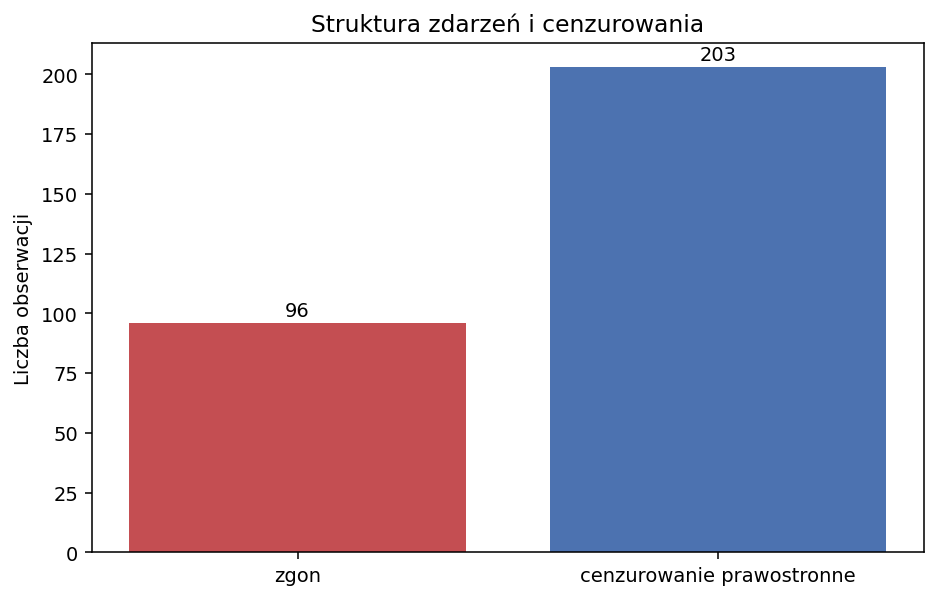

In [2]:
quantitative = [
    "time", "age", "ejection_fraction", "serum_creatinine",
    "serum_sodium", "platelets", "creatinine_phosphokinase"
]
desc = df[quantitative].agg(["count", "mean", "std", "min", "median", "max"]).T.round(2)
show("Statystyki opisowe zmiennych ilościowych", desc)

binary_vars = ["DEATH_EVENT", "anaemia", "diabetes", "high_blood_pressure", "sex", "smoking", "ef_low", "creatinine_high", "sodium_low"]
binary_summary = pd.DataFrame({
    "N=0": [(df[v] == 0).sum() for v in binary_vars],
    "N=1": [(df[v] == 1).sum() for v in binary_vars],
    "udział 1": [df[v].mean() for v in binary_vars],
}, index=binary_vars).round(3)
show("Zmienne binarne i zbinaryzowane", binary_summary)

censoring = pd.DataFrame({
    "status": ["zgon", "cenzurowanie prawostronne"],
    "liczba": [int(df["event"].sum()), int((1 - df["event"]).sum())],
})
censoring["udział"] = (censoring["liczba"] / len(df)).round(3)
show("Struktura zdarzeń i cenzurowania", censoring)

fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.bar(censoring["status"], censoring["liczba"], color=["#C44E52", "#4C72B0"])
ax.set(title="Struktura zdarzeń i cenzurowania", ylabel="Liczba obserwacji")
for i, value in enumerate(censoring["liczba"]):
    ax.text(i, value + 3, str(value), ha="center")
plt.tight_layout()


## Rozkład czasu obserwacji


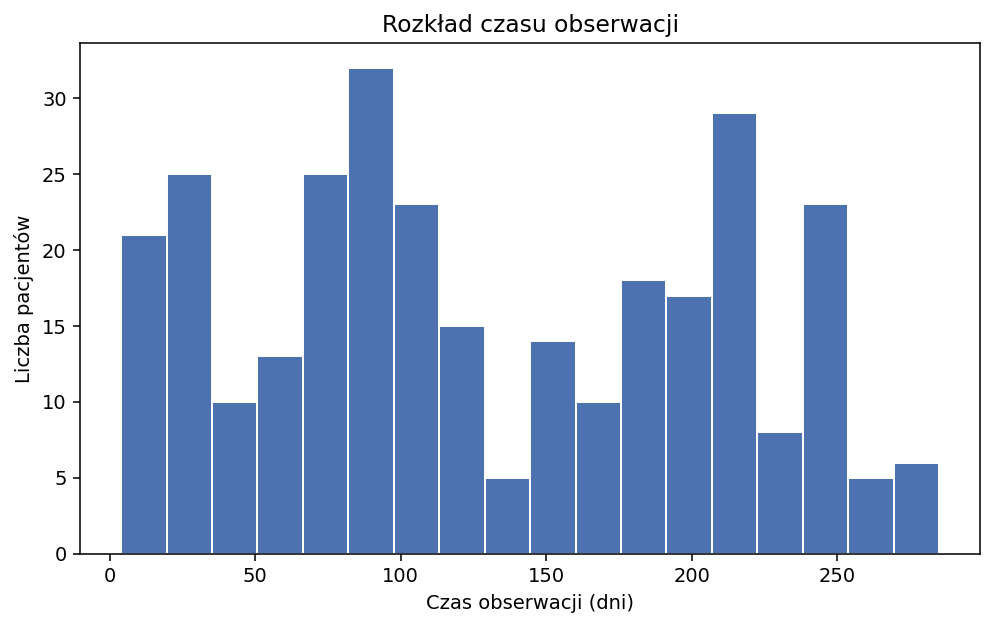

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.hist(df["duration"], bins=18, color="#4C72B0", edgecolor="white")
ax.set(title="Rozkład czasu obserwacji", xlabel="Czas obserwacji (dni)", ylabel="Liczba pacjentów")
plt.tight_layout()


## Estymator Kaplana-Meiera



Fragment tabeli Kaplana-Meiera
------------------------------
    czas  removed  zgony  cenzurowane  entrance  n_ryzyka    S(t)
0    0.0        0      0            0       299       299  1.0000
1    4.0        1      1            0         0       299  0.9967
2    6.0        1      1            0         0       298  0.9933
3    7.0        2      2            0         0       297  0.9866
4    8.0        2      2            0         0       295  0.9799
5   10.0        6      6            0         0       293  0.9599
6   11.0        2      2            0         0       287  0.9532
7   12.0        1      0            1         0       285  0.9532
8   13.0        1      1            0         0       284  0.9498
9   14.0        2      2            0         0       283  0.9431
10  15.0        2      2            0         0       281  0.9364
11  16.0        1      0            1         0       279  0.9364


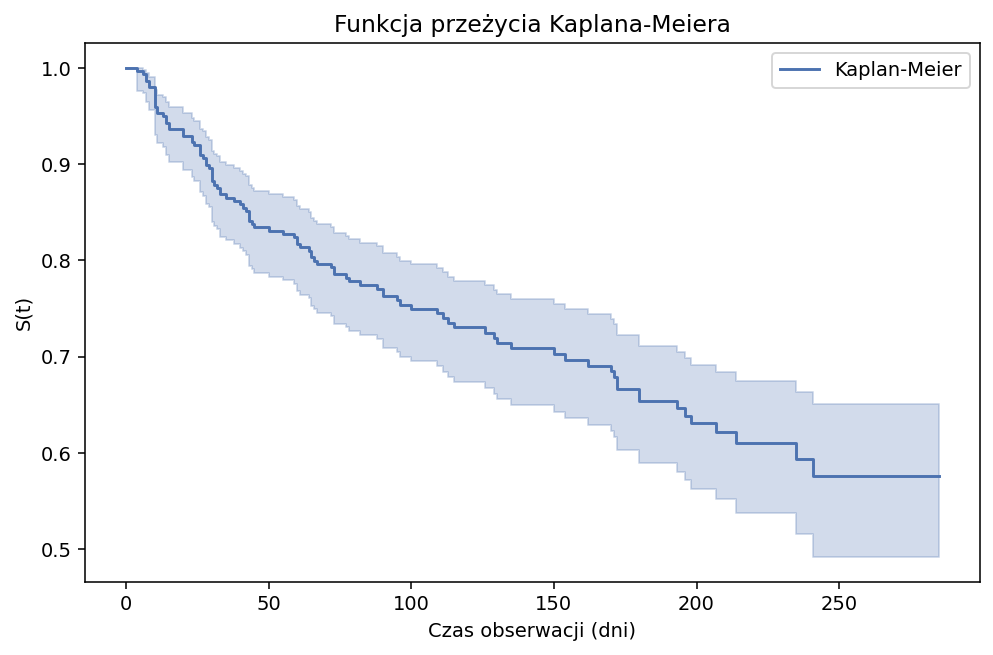

In [4]:
kmf = KaplanMeierFitter(label="Kaplan-Meier")
kmf.fit(df["duration"], event_observed=df["event"])

km_table = kmf.event_table.reset_index().rename(columns={
    "event_at": "czas", "at_risk": "n_ryzyka", "observed": "zgony", "censored": "cenzurowane"
})
km_surv = kmf.survival_function_.reset_index().rename(columns={"timeline": "czas", "Kaplan-Meier": "S(t)"})
km_fragment = km_table.merge(km_surv, on="czas", how="left").head(12).round(4)
show("Fragment tabeli Kaplana-Meiera", km_fragment)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
kmf.plot_survival_function(ci_show=True, ax=ax, color="#4C72B0")
ax.set(title="Funkcja przeżycia Kaplana-Meiera", xlabel="Czas obserwacji (dni)", ylabel="S(t)")
plt.tight_layout()


## Tablica aktuarialna



Tablica aktuarialna
-------------------
   przedział  n_początkowe  zgony  cenzurowane  n_efektywne       q   S_act       h
0     [0,30)           299     31            4        297.0  0.1044  0.8956  0.0035
1    [30,60)           264     21            4        262.0  0.0802  0.8238  0.0027
2    [60,90)           239     15           35        221.5  0.0677  0.7680  0.0023
3   [90,120)           189      9           35        171.5  0.0525  0.7277  0.0017
4  [120,150)           145      4           23        133.5  0.0300  0.7059  0.0010
5  [150,180)           118      7            5        115.5  0.0606  0.6632  0.0020
6  [180,210)           106      6           38         87.0  0.0690  0.6174  0.0023
7  [210,240)            62      2           26         49.0  0.0408  0.5922  0.0014
8  [240,285)            34      1           32         18.0  0.0556  0.5593  0.0012


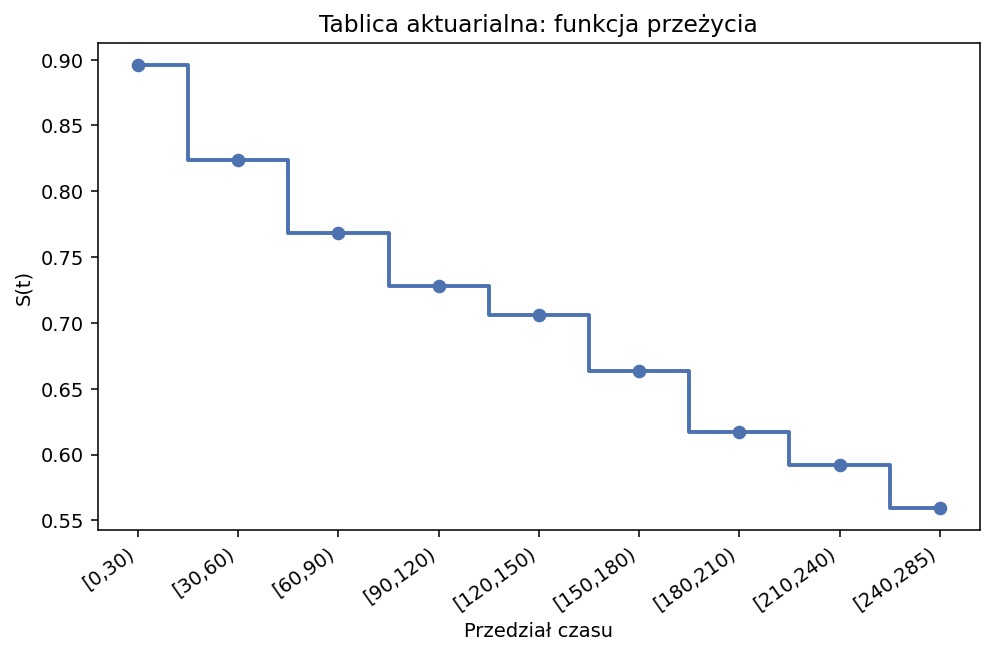

In [5]:
def life_table(data, breaks=(0, 30, 60, 90, 120, 150, 180, 210, 240, 285)):
    rows, survival = [], 1.0
    for start, end in zip(breaks[:-1], breaks[1:]):
        at_risk = int((data["duration"] >= start).sum())
        events = int(((data["duration"] >= start) & (data["duration"] < end) & (data["event"] == 1)).sum())
        censored = int(((data["duration"] >= start) & (data["duration"] < end) & (data["event"] == 0)).sum())
        effective = at_risk - censored / 2
        q = events / effective if effective > 0 else np.nan
        survival *= 1 - q if pd.notna(q) else 1
        hazard = events / (effective * (end - start)) if effective > 0 else np.nan
        rows.append([f"[{start},{end})", at_risk, events, censored, effective, q, survival, hazard])
    return pd.DataFrame(rows, columns=["przedział", "n_początkowe", "zgony", "cenzurowane", "n_efektywne", "q", "S_act", "h"])

actuarial = life_table(df)
show("Tablica aktuarialna", actuarial.round(4))

mids = np.arange(len(actuarial))
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.step(mids, actuarial["S_act"], where="mid", color="#4C72B0", lw=2)
ax.scatter(mids, actuarial["S_act"], color="#4C72B0")
ax.set_xticks(mids)
ax.set_xticklabels(actuarial["przedział"], rotation=35, ha="right")
ax.set(title="Tablica aktuarialna: funkcja przeżycia", xlabel="Przedział czasu", ylabel="S(t)")
plt.tight_layout()


## Nelson-Aalen i wygładzona funkcja hazardu



Wygładzony hazard Nelsona-Aalena: pierwsze wartości
---------------------------------------------------
      differenced-NA_estimate
0.0                  0.001902
4.0                  0.002106
6.0                  0.002196
7.0                  0.002239
8.0                  0.002280
10.0                 0.002358
11.0                 0.002400
12.0                 0.002441
13.0                 0.002480
14.0                 0.002517


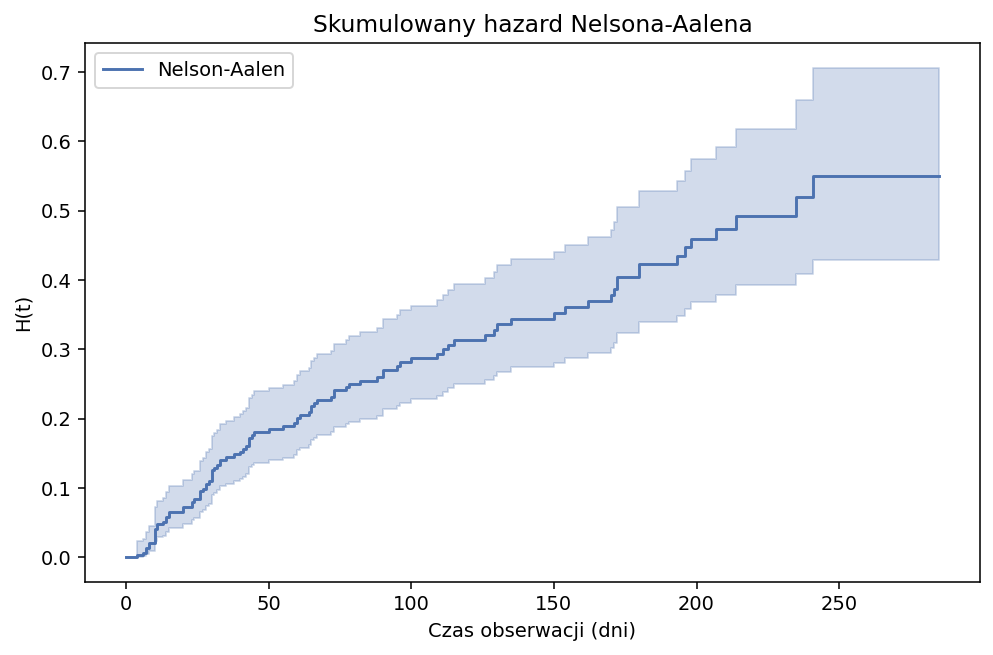

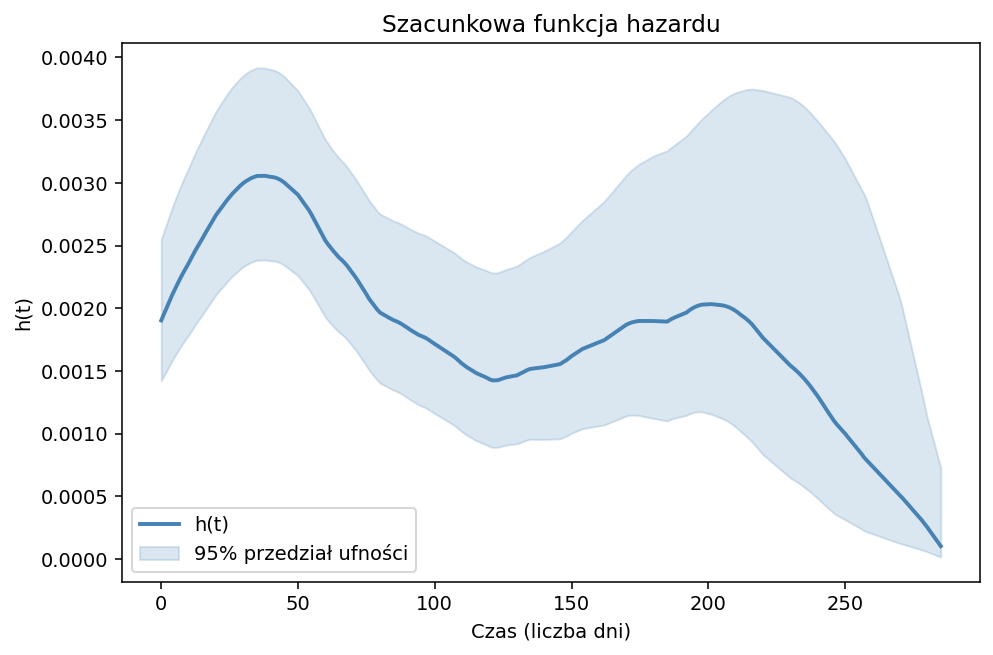

In [6]:
naf = NelsonAalenFitter(label="Nelson-Aalen")
naf.fit(df["duration"], event_observed=df["event"])

fig, ax = plt.subplots(figsize=(7.2, 4.8))
naf.plot_cumulative_hazard(ci_show=True, ax=ax, color="#4C72B0")
ax.set(title="Skumulowany hazard Nelsona-Aalena", xlabel="Czas obserwacji (dni)", ylabel="H(t)")
plt.tight_layout()

bandwidth = 50
naf2 = NelsonAalenFitter().fit(df["duration"], df["event"])
hazard = naf2.smoothed_hazard_(bandwidth)
hazard_ci = naf2.smoothed_hazard_confidence_intervals_(bandwidth)
show("Wygładzony hazard Nelsona-Aalena: pierwsze wartości", hazard.head(10).round(6))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(hazard.index, hazard.iloc[:, 0], color="steelblue", lw=2, label="h(t)")
ax.fill_between(hazard_ci.index, hazard_ci.iloc[:, 0], hazard_ci.iloc[:, 1],
                alpha=0.2, color="steelblue", label="95% przedział ufności")
ax.set(xlabel="Czas (liczba dni)", ylabel="h(t)", title="Szacunkowa funkcja hazardu")
ax.legend()
plt.tight_layout()


## Krzywe Kaplana-Meiera dla podgrup


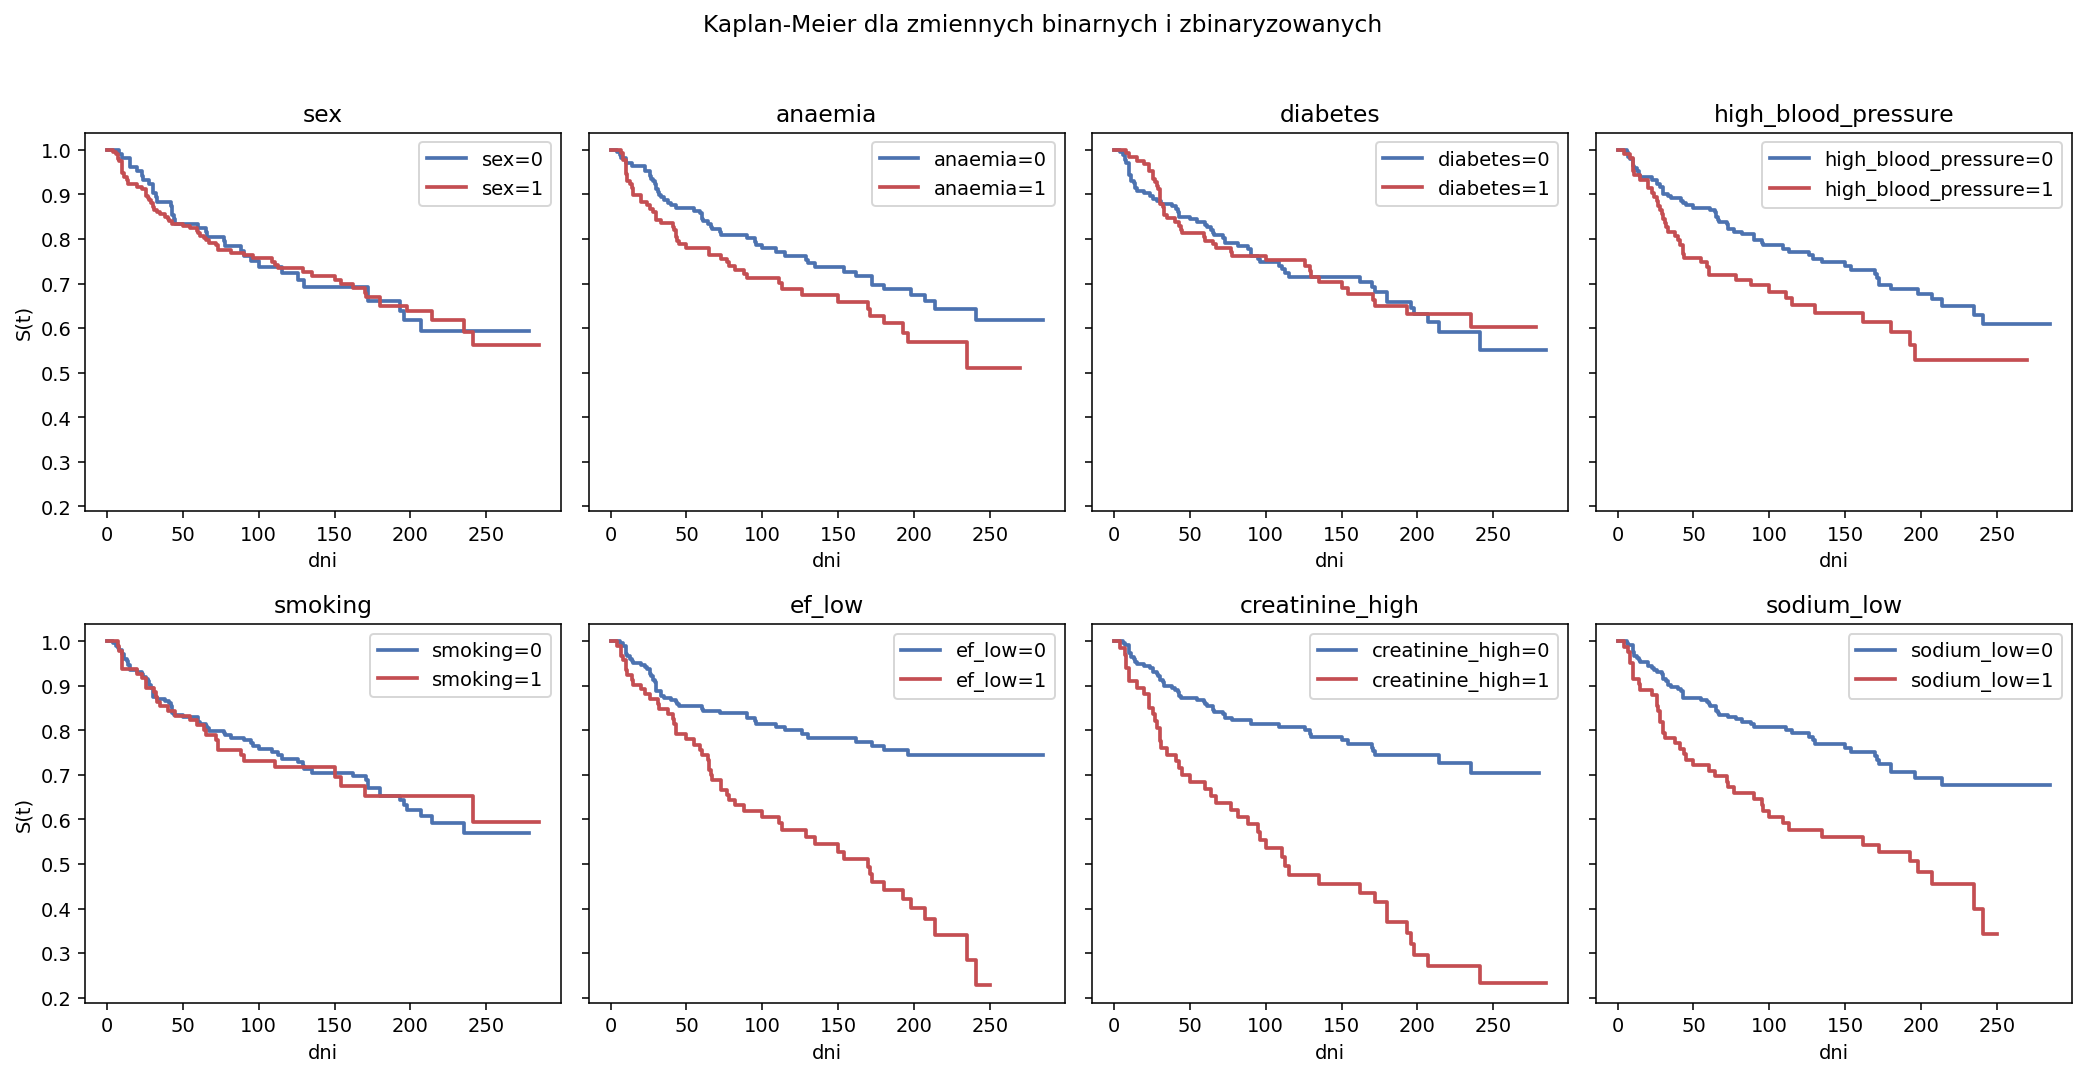

In [7]:
subgroup_vars = ["sex", "anaemia", "diabetes", "high_blood_pressure", "smoking", "ef_low", "creatinine_high", "sodium_low"]
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), sharey=True)
for ax, var in zip(axes.flat, subgroup_vars):
    for value, color in [(0, "#4C72B0"), (1, "#C44E52")]:
        mask = df[var] == value
        KaplanMeierFitter(label=f"{var}={value}").fit(df.loc[mask, "duration"], df.loc[mask, "event"]).plot_survival_function(
            ax=ax, ci_show=False, color=color, lw=1.9
        )
    ax.set_title(var)
    ax.set_xlabel("dni")
    ax.set_ylabel("S(t)")
fig.suptitle("Kaplan-Meier dla zmiennych binarnych i zbinaryzowanych", y=1.02)
plt.tight_layout()


## Testy log-rank i Wilcoxona


In [8]:
rows = []
for var in ["sex", "anaemia", "diabetes", "high_blood_pressure", "smoking", "ef_low", "creatinine_high"]:
    a = df[df[var] == 0]
    b = df[df[var] == 1]
    lr = logrank_test(a["duration"], b["duration"], event_observed_A=a["event"], event_observed_B=b["event"])
    wx = logrank_test(a["duration"], b["duration"], event_observed_A=a["event"], event_observed_B=b["event"], weightings="wilcoxon")
    rows.append([
        var, len(a), int(a["event"].sum()), len(b), int(b["event"].sum()),
        lr.test_statistic, lr.p_value, wx.test_statistic, wx.p_value
    ])
tests = pd.DataFrame(rows, columns=["zmienna", "N0", "zgony0", "N1", "zgony1", "logrank_chi2", "logrank_p", "wilcoxon_chi2", "wilcoxon_p"])
show("Wyniki testów nieparametrycznych", tests.round(4))



Wyniki testów nieparametrycznych
--------------------------------
               zmienna   N0  zgony0   N1  zgony1  logrank_chi2  logrank_p  wilcoxon_chi2  wilcoxon_p
0                  sex  105      34  194      62        0.0040     0.9498         0.0341      0.8534
1              anaemia  170      50  129      46        2.7265     0.0987         2.9239      0.0873
2             diabetes  174      56  125      40        0.0405     0.8405         0.0055      0.9411
3  high_blood_pressure  194      57  105      39        4.4062     0.0358         4.9273      0.0264
4              smoking  203      66   96      30        0.0020     0.9640         0.0600      0.8064
5               ef_low  206      45   93      51       30.6257     0.0000        18.5239      0.0000
6      creatinine_high  232      53   67      43       39.6117     0.0000        28.1866      0.0000


## Wnioski kontrolne

            Notebook odtwarza elementy nieparametryczne prezentacji na podstawie danych wejściowych: tabele opisowe, cenzurowanie, krzywe przeżycia, hazardy i testy różnic między podgrupami. Progi zmiennych zbinaryzowanych są jawnie zdefiniowane w sekcji przygotowania danych.
